# 3. Uncertainty: error bars by source mosaic

Needs no GPU. Reads the full-CAH detections from `01_full_cah`; runs no model.

Every number in `02_metrics` is a single figure. This notebook asks how much
each would move if the survey had covered different ground.

**Why mosaics, not patches.** The 2,607 patches are cut from 43 aerial mosaics.
Patches from one mosaic share a flight, the light, the altitude, the ground cover
and the herd's density, so they are not independent. Resampling patches would
give intervals too narrow for F1 and count bias, by 1.6x to 4.7x here (section
5 prints the ratios); for the empty-patch rate it makes little difference,
because that rate already turns on single patches. Resampling whole mosaics -
a cluster bootstrap - is the honest unit. It is also the finest grouping
above the patch that the data names: mosaic names carry a flight group (`GRP_n`) above it, and
mosaics from one group may share a flight, so even these intervals may run
optimistic.

**Why 43 and not 26.** `gt.csv` names a mosaic only for patches with animals.
Seventeen mosaics contributed nothing but empty ground, so they never appear
there. The mosaic is read from each patch's filename instead, and that rule is
checked against every recorded `base_images` value before it is used. If it
disagrees anywhere, the notebook stops.

**Paired comparisons.** Every model is scored on the same resampled mosaics, so
a difference between two models is measured on identical draws of the survey.
"Better" means higher for precision, recall and F1, lower for error and
false-alarm rates, and closer to zero for signed count bias.

**Caveat to carry with every interval.** 43 clusters, 26 with animals, is not
many; percentile intervals from a cluster bootstrap with this few clusters run
somewhat narrow. Read them as honest but optimistic.


In [10]:
# --- 0. Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# --- 1. Configuration ---
ASSETS  = "/content/drive/MyDrive/OWL_Caribou_Project"
RESULTS = "/content/drive/MyDrive/owl_caribou_overhead/results"

RUN_NAME   = "full_cah"
MODELS     = ["owl-d", "caribou-owl-c", "owl-c", "owl-t"]
PRIMARY    = "owl-d"
RADIUS     = 20.0     # headline radius; 40 px moved F1 by at most 0.005 for every model
N_BOOT     = 5000
CONFIDENCE = 0.95
SEED       = 0
COMPARISONS = [("owl-d", "caribou-owl-c"),   # the headline claim
               ("owl-t", "owl-c")]           # the two general models closest together

from pathlib import Path
if not (Path(ASSETS) / "data" / "test" / "gt.csv").is_file():
    raise RuntimeError(f"{ASSETS}/data/test/gt.csv not found. Put the assets there as the README's "
                       "'Expected assets' section describes, or point ASSETS at where they are.")


In [ ]:
# === CODE SYNC (auto-generated by `python -m owlcaribou.sync`, do not edit) ===
raise RuntimeError("The sync cell is empty. On your own machine, in the project folder, run:  python -m owlcaribou.sync   and reopen this notebook.")

In [13]:
# --- 3. Start the session (no GPU needed) ---
from owlcaribou.session import start_session

session = start_session(assets=ASSETS, results=RESULTS,
                        require_gpu=False, verify_assets=False)

session: Colab | device cuda (NVIDIA A100-SXM4-40GB, 39.49 GB)
  torch   2.11.0+cu128 | CUDA 12.8 | Python 3.13.15
  assets  /content/drive/MyDrive/OWL_Caribou_Project
  results /content/drive/MyDrive/owl_caribou_overhead/results
  code    c26c4d3f466e


In [14]:
# --- 4. Load, check the mosaic rule, and reduce each patch to summable statistics ---
import numpy as np
from owlcaribou import io as oio, metrics, uncertainty as U
from owlcaribou.data import load_ground_truth, mosaic_from_patch_name, verify_mosaic_rule

run = session.paths.run_dir(RUN_NAME)
out = run / "uncertainty"

truth = load_ground_truth(session.paths.ground_truth)
patch_names = [row["images"] for row in oio.read_csv(run / PRIMARY / "per_image.csv")]
assert len(patch_names) == 2607, f"expected 2607 evaluated patches, found {len(patch_names)}"

rule = verify_mosaic_rule(patch_names, truth)   # raises if the filename rule is wrong anywhere
print("mosaic rule verified:", rule)
groups = [mosaic_from_patch_name(name) for name in patch_names]

# Every model must be complete and come from one run of one code version.
run_code = oio.require_one_run(run, MODELS)
print(f"detections: one run of all {len(MODELS)} models, code {run_code}")

statistics = {}
for model in MODELS:
    directory = run / model
    predictions = metrics.load_predictions(directory / "detections.csv")
    statistics[model] = U.patch_statistics(predictions, truth, patch_names, RADIUS)

# The decomposition must reproduce the pooled metrics exactly, or the intervals
# would describe something other than the reported numbers.
for model, stats in statistics.items():
    pooled = U.metrics_from_totals(stats.sum(axis=0))
    reference = metrics.evaluate(metrics.load_predictions(run / model / "detections.csv"),
                                 truth, patch_names, RADIUS)
    diffs = np.array([abs(pooled[k][0] - getattr(reference, k)) for k in U.METRICS])
    # isfinite first: max() would quietly skip a NaN from one undefined metric
    drift = dict(zip(U.METRICS, diffs))
    assert np.all(np.isfinite(diffs)) and diffs.max() < 1e-12, f"{model}: drift {drift}"
print("per-patch statistics reproduce the pooled metrics exactly")

mosaic rule verified: {'patches': 2607, 'annotated_checked': 1852, 'mosaics': 43, 'mosaics_with_animals': 26, 'background_only_mosaics': 17}
detections: one run of all 4 models, code c26c4d3f466e
per-patch statistics reproduce the pooled metrics exactly


In [15]:
# --- 5. Cluster bootstrap over mosaics ---
result = U.cluster_bootstrap(statistics, groups, n_boot=N_BOOT,
                             confidence=CONFIDENCE, seed=SEED)
oio.write_csv(out / "intervals.csv", result.table())

pct = int(CONFIDENCE * 100)
print(f"{len(result.labels)} mosaics resampled {N_BOOT} times, {pct}% percentile intervals, "
      f"radius {RADIUS:.0f} px\n")
print(f"{'model':14s} {'F1':>7s}  {'interval':^14s}   {'bias %':>8s}  {'interval':^18s}   "
      f"{'emptyFP':>7s}  {'interval':^14s}")
for model in result.models:
    p, lo, hi = result.point[model], result.low[model], result.high[model]
    print(f"{model:14s} {p['f1_score']:7.3f}  [{lo['f1_score']:.3f}, {hi['f1_score']:.3f}]   "
          f"{p['aggregate_count_bias_percent']:+8.2f}  "
          f"[{lo['aggregate_count_bias_percent']:+7.2f}, {hi['aggregate_count_bias_percent']:+7.2f}]   "
          f"{p['empty_patch_false_positive_rate']:7.3f}  "
          f"[{lo['empty_patch_false_positive_rate']:.3f}, {hi['empty_patch_false_positive_rate']:.3f}]")

undefined = {m: max(result.undefined[m].values()) for m in result.models}
if any(undefined.values()):
    print("\nreplicates with an undefined metric (excluded):", undefined)

# How much narrower would resampling patches have been? One group per patch.
naive = U.cluster_bootstrap(statistics, patch_names, n_boot=N_BOOT,
                            confidence=CONFIDENCE, seed=SEED)
print("\nmosaic interval width over patch-resampled width (F1 / bias % / emptyFP):")
for model in result.models:
    ratios = [(result.high[model][m] - result.low[model][m])
              / (naive.high[model][m] - naive.low[model][m])
              for m in ("f1_score", "aggregate_count_bias_percent",
                        "empty_patch_false_positive_rate")]
    print(f"  {model:14s} " + "   ".join(f"{r:4.1f}x" for r in ratios))

43 mosaics resampled 5000 times, 95% percentile intervals, radius 20 px

model               F1     interval        bias %       interval        emptyFP     interval   
owl-d            0.962  [0.958, 0.966]      +0.31  [  -1.05,   +2.03]     0.013  [0.006, 0.022]
caribou-owl-c    0.946  [0.934, 0.953]      +9.26  [  +7.06,  +12.58]     0.062  [0.043, 0.083]
owl-c            0.857  [0.832, 0.874]      +2.55  [  -4.86,  +12.73]     0.065  [0.044, 0.091]
owl-t            0.874  [0.859, 0.889]      -3.85  [  -9.67,   +3.93]     0.049  [0.029, 0.073]

mosaic interval width over patch-resampled width (F1 / bias % / emptyFP):
  owl-d           1.6x    2.8x    1.0x
  caribou-owl-c   2.6x    3.6x    1.1x
  owl-c           2.7x    4.7x    1.3x
  owl-t           2.4x    4.6x    1.4x


In [16]:
# --- 6. Paired comparisons on identical resampled mosaics ---
rows = []
for a, b in COMPARISONS:
    print(f"\n{a}  minus  {b}")
    for metric in ("f1_score", "precision", "recall", "count_mae",
                   "aggregate_count_bias_percent", "empty_patch_false_positive_rate"):
        d = result.difference(a, b, metric)
        rows.append(d)
        print(f"  {metric:32s} {d['estimate']:+9.4f}  [{d['ci_low']:+9.4f}, {d['ci_high']:+9.4f}]"
              f"   {a} better in {d['share_a_better']:6.1%} of replicates")
oio.write_csv(out / "paired_differences.csv", rows)

print("\nFor precision, recall, F1 and the error and false-alarm metrics, an interval that")
print("excludes zero is a difference that survives resampling the survey. For signed")
print("count bias read the share column: its difference interval only says the two")
print("biases differ, not which sits closer to zero. Near 50% is a coin toss.")


owl-d  minus  caribou-owl-c
  f1_score                           +0.0161  [  +0.0096,   +0.0266]   owl-d better in 100.0% of replicates
  precision                          +0.0548  [  +0.0446,   +0.0713]   owl-d better in 100.0% of replicates
  recall                             -0.0263  [  -0.0305,   -0.0204]   owl-d better in   0.0% of replicates
  count_mae                          -0.2064  [  -0.3173,   -0.1342]   owl-d better in 100.0% of replicates
  aggregate_count_bias_percent       -8.9595  [ -11.1736,   -7.6369]   owl-d better in 100.0% of replicates
  empty_patch_false_positive_rate    -0.0490  [  -0.0656,   -0.0331]   owl-d better in 100.0% of replicates

owl-t  minus  owl-c
  f1_score                           +0.0170  [  +0.0020,   +0.0374]   owl-t better in  98.9% of replicates
  precision                          +0.0452  [  +0.0242,   +0.0735]   owl-t better in 100.0% of replicates
  recall                             -0.0108  [  -0.0313,   +0.0057]   owl-t better in

owl-d F1 across 26 mosaics with animals: min 0.870, median 0.960, max 1.000
17 background-only mosaics; owl-d raised a false alarm in 3 of them
the 43 mosaics come from 13 flight groups (GRP prefixes); mosaics from one group may share a flight

weakest mosaics:
  F1 0.870    13 patches     12 animals  east_GRP_13_50mm_mosaic_1_0 | 50mm
  F1 0.880    12 patches     11 animals  west_GRP_8_50mm_mosaic_2_0 | 50mm
  F1 0.909     3 patches      5 animals  west_GRP_8_90mm_mosaic_0_0 | 90mm
  F1 0.930     9 patches     20 animals  west_GRP_4_50mm_mosaic_0_0 | 50mm
  F1 0.933     2 patches      8 animals  west_GRP_6_50mm_mosaic_0_0 | 50mm


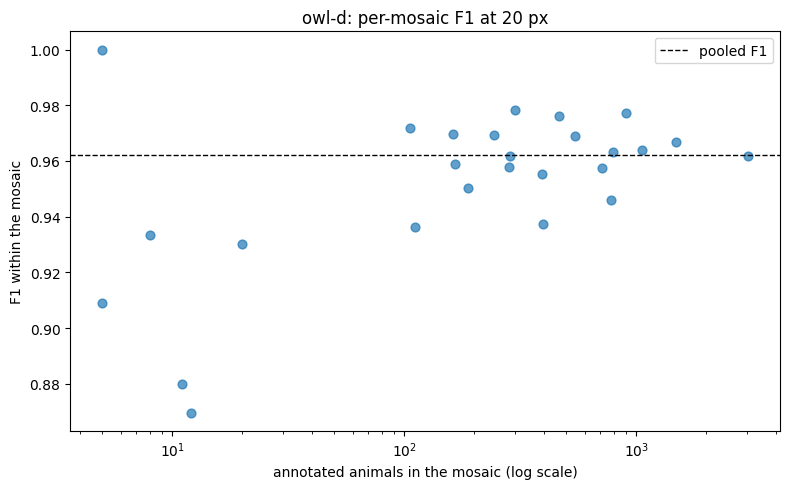

Small mosaics scatter most: one missed animal in ten moves F1 by several points.


In [17]:
# --- 7. How much does the primary model vary from mosaic to mosaic? ---
import re
import matplotlib.pyplot as plt
import numpy as np

per_mosaic = U.per_group_metrics(statistics[PRIMARY], groups)
oio.write_csv(out / f"{PRIMARY}_per_mosaic.csv", per_mosaic)

with_animals = [g for g in per_mosaic if g["annotated_points"] > 0]
background   = [g for g in per_mosaic if g["annotated_points"] == 0]
f1 = np.array([g["f1_score"] for g in with_animals])
print(f"{PRIMARY} F1 across {len(with_animals)} mosaics with animals: "
      f"min {f1.min():.3f}, median {np.median(f1):.3f}, max {f1.max():.3f}")

false_alarm_mosaics = [g for g in background if g["empty_patch_false_positive_rate"] > 0]
print(f"{len(background)} background-only mosaics; {PRIMARY} raised a false alarm in "
      f"{len(false_alarm_mosaics)} of them")

flight_groups = {re.sub(r"_\d+mm_mosaic.*$", "", g["group"]) for g in per_mosaic}
print(f"the {len(per_mosaic)} mosaics come from {len(flight_groups)} flight groups (GRP prefixes); "
      "mosaics from one group may share a flight")

print("\nweakest mosaics:")
for g in sorted(with_animals, key=lambda g: g["f1_score"])[:5]:
    label = g["group"].replace("CAH_20220630_", "").replace("_post_processed_seamline_", " | ")
    print(f"  F1 {g['f1_score']:.3f}  {g['patches']:4d} patches  {g['annotated_points']:5d} animals  {label}")

points = np.array([g["annotated_points"] for g in with_animals])
plt.figure(figsize=(8, 5))
plt.scatter(points, f1, s=40, alpha=0.7)
plt.axhline(result.point[PRIMARY]["f1_score"], color="black", linestyle="--", linewidth=1,
            label="pooled F1")
plt.xscale("log")
plt.xlabel("annotated animals in the mosaic (log scale)")
plt.ylabel("F1 within the mosaic")
plt.title(f"{PRIMARY}: per-mosaic F1 at {RADIUS:.0f} px")
plt.legend()
plt.tight_layout()
plt.savefig(out / f"{PRIMARY}_per_mosaic.png", dpi=160)
plt.show()
print("Small mosaics scatter most: one missed animal in ten moves F1 by several points.")

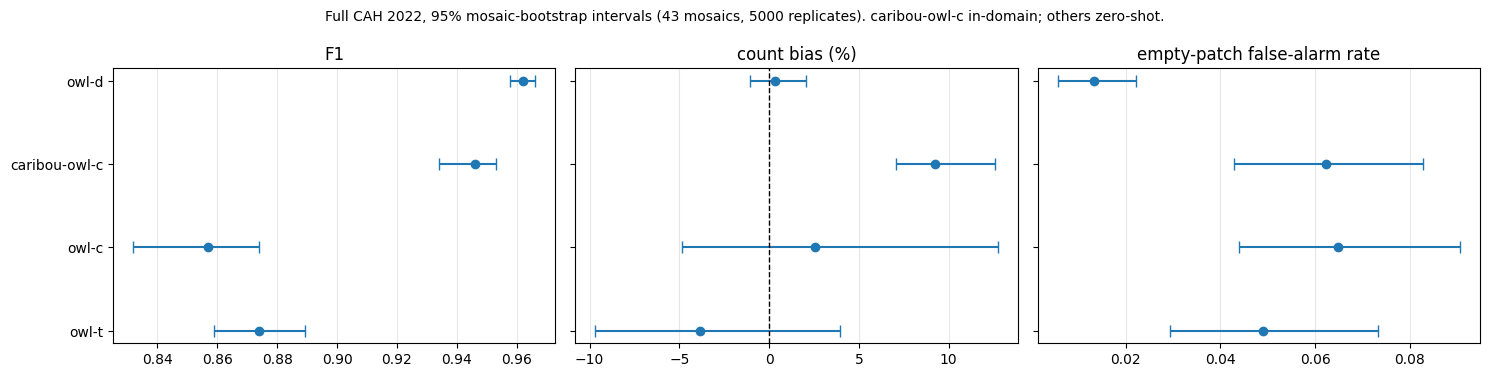

written to /content/drive/MyDrive/owl_caribou_overhead/results/full_cah/uncertainty


In [18]:
# --- 8. Intervals side by side ---
import matplotlib.pyplot as plt
import numpy as np

panels = [("f1_score", "F1", False),
          ("aggregate_count_bias_percent", "count bias (%)", True),
          ("empty_patch_false_positive_rate", "empty-patch false-alarm rate", False)]
models = result.models
y = np.arange(len(models))[::-1]

figure, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for axis, (metric, title, zero_line) in zip(axes, panels):
    point = np.array([result.point[m][metric] for m in models])
    low   = np.array([result.low[m][metric] for m in models])
    high  = np.array([result.high[m][metric] for m in models])
    axis.errorbar(point, y, xerr=[point - low, high - point], fmt="o", capsize=4)
    if zero_line:
        axis.axvline(0, color="black", linestyle="--", linewidth=1)
    axis.set_title(title)
    axis.grid(axis="x", alpha=0.3)
axes[0].set_yticks(y)
axes[0].set_yticklabels(models)
figure.suptitle(f"Full CAH 2022, {int(CONFIDENCE * 100)}% mosaic-bootstrap intervals "
                f"({len(result.labels)} mosaics, {N_BOOT} replicates). "
                "caribou-owl-c in-domain; others zero-shot.", fontsize=10)
plt.tight_layout()
plt.savefig(out / "intervals.png", dpi=160)
plt.show()

session.record(out, radius=RADIUS, n_boot=N_BOOT, confidence=CONFIDENCE, seed=SEED,
               mosaics=len(result.labels), mosaic_rule=rule)
print("written to", out)

## Reading these intervals

**Two intervals that do not overlap** are a difference that survives resampling
the survey. Two that overlap may still differ - the paired comparison in
section 6 is the test for that, because it removes the variation both models
share.

**A bias interval that contains zero** means the model cannot be shown to
over- or under-count. One that excludes zero is a systematic lean.

**The per-mosaic spread** says how much any single survey flight could deviate
from the pooled figure. The weakest mosaics are usually the smallest, where one
missed animal is a large fraction of the total.

## What these intervals do not cover

- **Other herds, years or sensors.** Resampling these 43 mosaics describes
  variation within the CAH 2022 survey, not transfer to new conditions.
- **Annotation error.** The ground truth is treated as exact.
- **The asymmetric comparison.** `caribou-owl-c`'s operating point was chosen
  on CAH. An interval does not correct for that; it only measures noise.
- **Shared flights.** Mosaics from one flight group are treated as independent
  clusters; if they share a flight, the intervals are narrower than they should be.

**Next:** `04_failures.ipynb`.
